In [100]:
import cv2
from retinaface import RetinaFace
import matplotlib.pyplot as plt
import os
from xiaoying.toolkit import detect, align
from tqdm import tqdm
import torch
from xiaoying import net
from torchvision import transforms
from xiaoying.ViT.load_models import load_vit_base
import torch.nn as nn
from PIL import Image

In [127]:
base = r'xiaoying\toolkit\images\hanli'
result = {}
for file in tqdm(os.listdir(base)):
    img_path = os.path.join(base, file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    detections = detect.detect_faces(img)
    if len(detections) > 0:
        result[file] = detect.extract_face(img, detections[0])

100%|██████████| 8/8 [00:59<00:00,  7.40s/it]


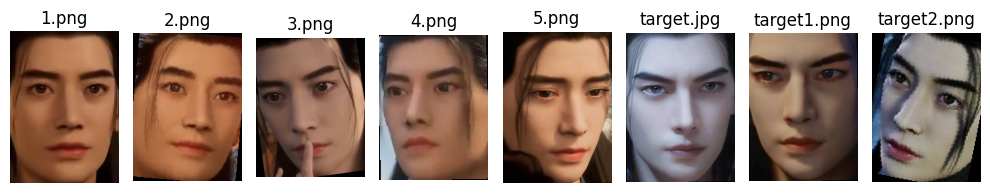

In [131]:
plt.figure(figsize=(10, 10))
for i, (file, (face, landmarks, bbox)) in enumerate(result.items()):
    face, _ = align.alignment_procedure(face, landmarks)
    plt.subplot(1, len(result), i + 1)
    plt.imshow(face)
    plt.title(file)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
device = torch.device('cuda')
print(device)

vit = load_vit_base()
vit.load_state_dict(torch.load('C:\MINH\models\ViT_base.pth'))

class ViT(nn.Module):
    def __init__(self, model):
        super(ViT, self).__init__()
        self.model = model
        
    def forward(self, x):
        x = self.model(x)
        norm = torch.norm(x, 2, 1, True)
        output = torch.div(x, norm)
        return output, norm

model = ViT(vit)

model.to(device);

cuda
Loaded ViT model
compatible keys in state_dict 281 / 281
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt


In [133]:
images = []
targets = []
for file, (face, _, _) in result.items():
    face, _ = align.alignment_procedure(face, landmarks)
    if 'target' in file:
        targets.append(face)
    else:
        images.append(face)
print(len(images), len(targets))

5 3


In [134]:
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

In [135]:
images = [transform(cv2.resize(image, (112, 112))) for image in images]
targets = [transform(cv2.resize(target, (112, 112))) for target in targets]
print(images[0].shape)

torch.Size([3, 112, 112])


In [136]:
images = torch.stack(images)
targets = torch.stack(targets)
print(images.shape, targets.shape)

torch.Size([5, 3, 112, 112]) torch.Size([3, 3, 112, 112])


In [137]:
model.eval()
with torch.no_grad():
    embeddings, _ = model(images.to(device))
    target_embeddings, _ = model(targets.to(device))
    
print(embeddings.shape, target_embeddings.shape)

torch.Size([5, 512]) torch.Size([3, 512])


In [170]:
cosine = torch.cosine_similarity(
    torch.mean(embeddings, dim=0, keepdim=True),
    torch.mean(target_embeddings, dim=0, keepdim=True)
)
print(cosine)

tensor([0.6845], device='cuda:0')


In [171]:
cosine = torch.cosine_similarity(
    embeddings.max(dim=0)[0],
    target_embeddings.max(dim=0)[0],
    dim=0
)
print(cosine)

tensor(0.7422, device='cuda:0')
